# EDA: Animal NER Dataset (small synthetic dataset)

**Goal**: understand dataset structure, class balance, sentence patterns, animal distribution, and annotation characteristics.

**Dataset size**: ~76 examples
**Task**: binary NER (0 = O, 1 = ANIMAL)

---

In [2]:
import json
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Better visuals in Jupyter
%matplotlib inline
sns.set(style="whitegrid", font_scale=1.3)
plt.rcParams["figure.figsize"] = (10, 6)

In [12]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("json", data_files="labels.json")

data = dataset["train"]

# Convert to plain Python list of dicts
examples = data.to_list()

print(f"Loaded examples: {len(examples)}")
print("First example:")
print(examples[0])

Loaded examples: 303
First example:
{'tokens': ['There', 'is', 'a', 'beautiful', 'butterfly', 'in', 'the', 'picture', '.'], 'ner_tags': [0, 0, 0, 0, 1, 0, 0, 0, 0]}


Basic statistics

In [13]:
total_examples = len(data)

# Sentences containing at least one ANIMAL
sent_with_animal = sum(1 for ex in data if 1 in ex["ner_tags"])
sent_without = total_examples - sent_with_animal

print(f"Total examples             : {total_examples}")
print(f"With animal (tag=1)        : {sent_with_animal} ({sent_with_animal/total_examples:.1%})")
print(f"Without animal             : {sent_without}   ({sent_without/total_examples:.1%})")

# Tag distribution
all_tags = []
for ex in data:
    all_tags.extend(ex["ner_tags"])

tag_counts = Counter(all_tags)
print("\nTag distribution:")
for tag, cnt in sorted(tag_counts.items()):
    print(f"  tag {tag:2d} : {cnt:5,d}  ({cnt/len(all_tags):.1%})")

Total examples             : 303
With animal (tag=1)        : 200 (66.0%)
Without animal             : 103   (34.0%)

Tag distribution:
  tag  0 : 1,682  (89.4%)
  tag  1 :   200  (10.6%)


Most frequent animals

Most frequent animals (by tag=1 count):
  butterfly    : 20
  cat          : 20
  chicken      : 20
  dog          : 20
  cow          : 20
  elephant     : 20
  horse        : 20
  sheep        : 20
  spider       : 20
  squirrel     : 20


C:\Users\Ivan\AppData\Local\Temp\ipykernel_15356\1662609684.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=animals, palette="viridis")


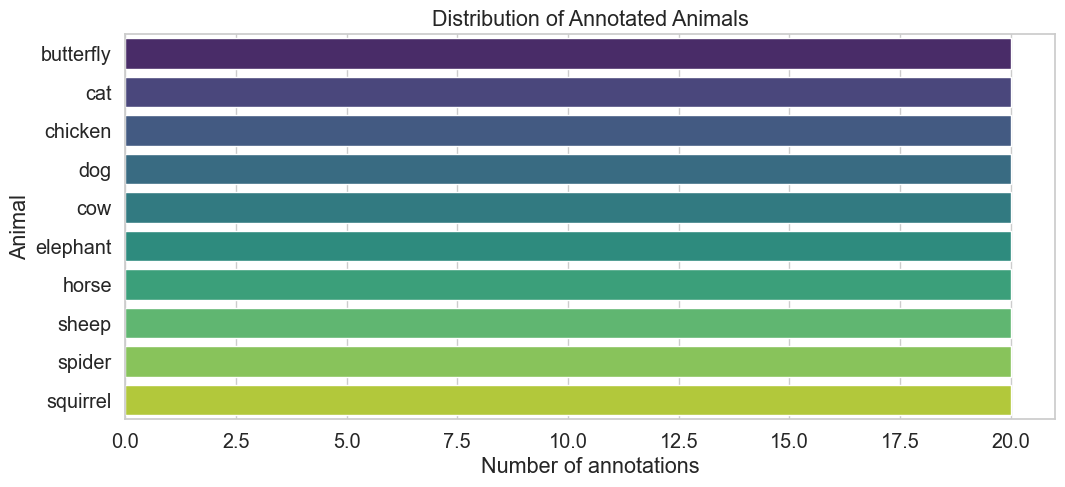

In [14]:
animal_counter = Counter()

for ex in data:
    for token, tag in zip(ex["tokens"], ex["ner_tags"]):
        if tag == 1:
            animal_counter[token.lower()] += 1

print("Most frequent animals (by tag=1 count):")
for animal, cnt in animal_counter.most_common():
    print(f"  {animal:12} : {cnt:2d}")

# Bar plot
animals = list(animal_counter.keys())
counts  = list(animal_counter.values())

plt.figure(figsize=(12, 5))
sns.barplot(x=counts, y=animals, palette="viridis")
plt.title("Distribution of Annotated Animals")
plt.xlabel("Number of annotations")
plt.ylabel("Animal")
plt.show()